# Fase 3 — Desagregación Temporal Trimestral → Mensual

**Proyecto:** Crédito Remesa Jalisco — Modelos de Crédito (ITESO)

Este notebook valida la desagregación temporal Chow-Lin AR(1) producida por `09_desagregacion_temporal.py` y diagnostica la calidad del fit.

## Estructura
1. Carga y validación básica
2. Distribución global del rho AR(1) y R² OLS
3. Verificación de la restricción de agregación
4. Comparación trimestre observado vs trimestre reconstruido (5 municipios representativos)
5. Visualización de la dinámica mensual estimada
6. Comparación contra la serie nacional indicadora
7. Conclusiones para reporte APA7

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
MENSUAL_CSV = PROJECT_ROOT / 'data' / 'processed' / 'jalisco_municipal_remesas_mensuales.csv'
TRIMESTRAL_CSV = PROJECT_ROOT / 'data' / 'raw' / 'banxico_ce166_jalisco_trimestral.csv'
INDICADORA_CSV = PROJECT_ROOT / 'data' / 'raw' / 'banxico_se27803_remesas_mensuales_nacional.csv'
METADATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'jalisco_municipal_remesas_mensuales_metadata.json'

df_mensual = pd.read_csv(MENSUAL_CSV, parse_dates=['fecha'])
df_mensual['cve_municipio'] = df_mensual['cve_municipio'].astype(str).str.zfill(5)

df_trim = pd.read_csv(TRIMESTRAL_CSV, parse_dates=['fecha'])
df_trim['cve_municipio'] = df_trim['cve_municipio'].astype(str).str.zfill(5)
df_trim = df_trim[df_trim['fecha'].dt.year <= 2024].copy()

df_nac = pd.read_csv(INDICADORA_CSV, parse_dates=['fecha'])
df_nac = df_nac[df_nac['fecha'].dt.year <= 2024].copy()

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

print(f'Mensual desagregada: {df_mensual.shape}')
print(f'Trimestral CE166:   {df_trim.shape}')
print(f'Nacional SE27803:   {df_nac.shape}')
print(f'Método principal:   {meta["n_municipios_chow_lin"]} municipios')
print(f'Método fallback:    {meta["n_municipios_fallback"]} municipios')

Mensual desagregada: (17856, 4)
Trimestral CE166:   (5952, 6)
Nacional SE27803:   (144, 2)
Método principal:   124 municipios
Método fallback:    0 municipios


## 2. Distribución global del rho AR(1) y R² OLS

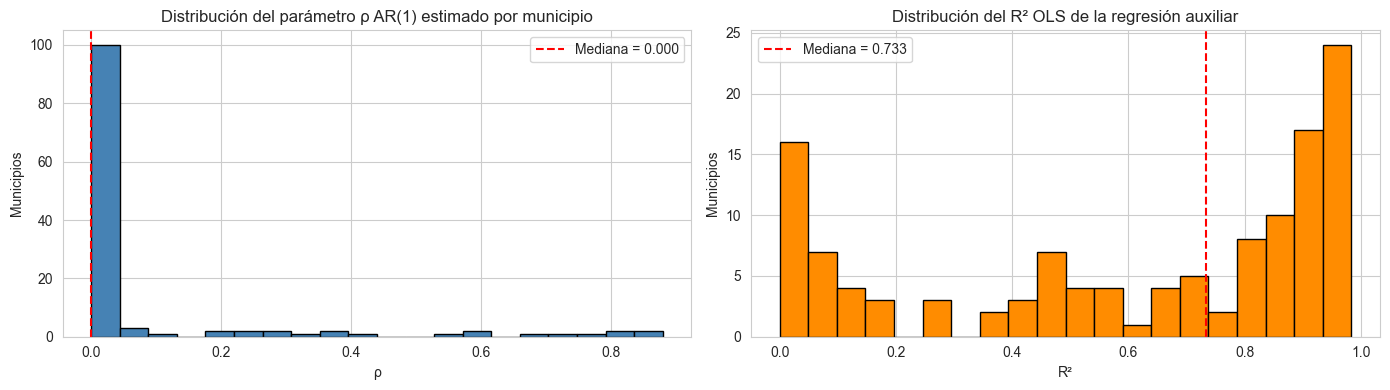

        rho_ar1    r2_ols
count  124.0000  124.0000
mean     0.0851    0.6005
std      0.2114    0.3563
min      0.0000    0.0000
25%      0.0000    0.2673
50%      0.0000    0.7334
75%      0.0000    0.9181
max      0.8800    0.9839


In [3]:
diag = meta['diagnostico_por_municipio']
df_diag = pd.DataFrame.from_dict(diag, orient='index')
df_diag.index.name = 'cve_municipio'

df_diag_cl = df_diag[df_diag['metodo'] == 'chow_lin_ar1'].copy()
df_diag_cl['rho_ar1'] = df_diag_cl['rho_ar1'].astype(float)
df_diag_cl['r2_ols'] = df_diag_cl['r2_ols'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_diag_cl['rho_ar1'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución del parámetro ρ AR(1) estimado por municipio')
axes[0].set_xlabel('ρ')
axes[0].set_ylabel('Municipios')
axes[0].axvline(df_diag_cl['rho_ar1'].median(), color='red', linestyle='--', label=f'Mediana = {df_diag_cl["rho_ar1"].median():.3f}')
axes[0].legend()

axes[1].hist(df_diag_cl['r2_ols'], bins=20, color='darkorange', edgecolor='black')
axes[1].set_title('Distribución del R² OLS de la regresión auxiliar')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Municipios')
axes[1].axvline(df_diag_cl['r2_ols'].median(), color='red', linestyle='--', label=f'Mediana = {df_diag_cl["r2_ols"].median():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_diag_cl[['rho_ar1', 'r2_ols']].describe().round(4))

## 3. Verificación de la restricción de agregación

Por construcción del método Chow-Lin, la suma de los 3 valores mensuales estimados de cada trimestre debe ser exactamente igual al valor trimestral observado (CE166). Verificamos numéricamente.

In [4]:
# Calcular suma trimestral desde la serie mensual estimada
df_check = df_mensual.copy()
df_check['trimestre_inicio'] = df_check['fecha'].dt.to_period('Q').dt.start_time
agg = df_check.groupby(['cve_municipio', 'trimestre_inicio'], as_index=False)['remesas_musd_mensual'].sum()
agg.rename(columns={'remesas_musd_mensual': 'suma_3meses', 'trimestre_inicio': 'fecha'}, inplace=True)

merged = agg.merge(df_trim, on=['cve_municipio', 'fecha'], how='inner')
merged['error_abs'] = (merged['suma_3meses'] - merged['remesas_musd']).abs()

print(f'Total de comparaciones: {len(merged)}')
print(f'Error máximo absoluto:  {merged["error_abs"].max():.2e}')
print(f'Error medio absoluto:   {merged["error_abs"].mean():.2e}')
print(f'Comparaciones con error > 1e-6: {(merged["error_abs"] > 1e-6).sum()}')

if merged['error_abs'].max() < 1e-6:
    print('\n✓ La restricción de agregación se satisface dentro de la precisión numérica.')
else:
    print('\n✗ Hay errores de agregación; revisar implementación.')

Total de comparaciones: 5952
Error máximo absoluto:  1.00e-10
Error medio absoluto:   2.37e-11
Comparaciones con error > 1e-6: 0

✓ La restricción de agregación se satisface dentro de la precisión numérica.


## 4. Comparación trimestre observado vs trimestre reconstruido — 5 municipios representativos

Se eligen cinco municipios con perfiles distintos:
- **Guadalajara (14039):** capital, alto volumen absoluto.
- **Zapopan (14120):** segundo municipio más poblado.
- **Mezquitic (14061):** rural norte, alta intensidad migratoria.
- **Unión de Tula (14110):** alta remesa per cápita.
- **Tepatitlán de Morelos (14093):** ciudad media, perfil mixto.

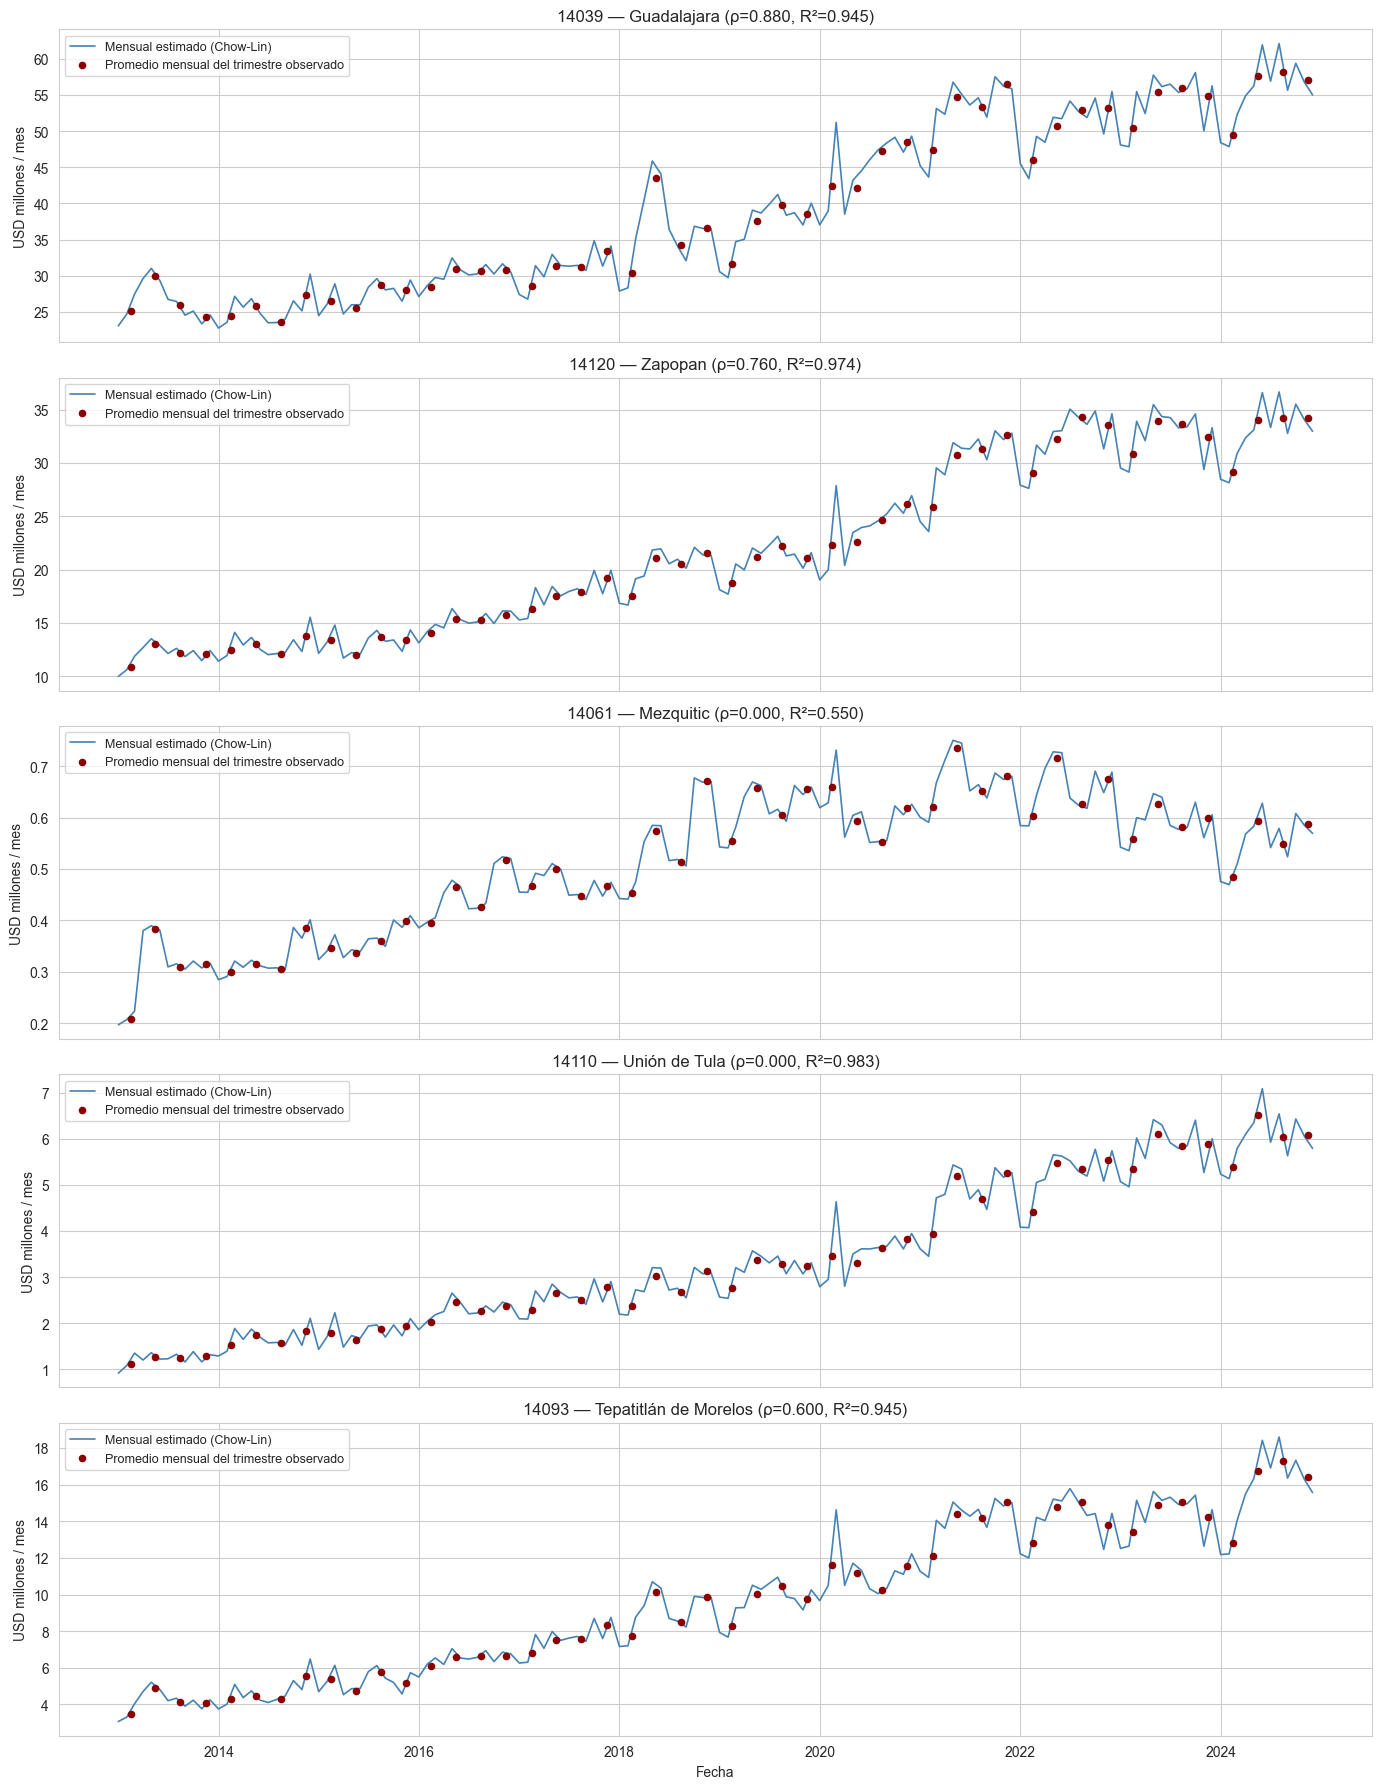

In [5]:
MUNICIPIOS_FOCO = ['14039', '14120', '14061', '14110', '14093']
NOMBRES_FOCO = {
    '14039': 'Guadalajara',
    '14120': 'Zapopan',
    '14061': 'Mezquitic',
    '14110': 'Unión de Tula',
    '14093': 'Tepatitlán de Morelos',
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, cve in zip(axes, MUNICIPIOS_FOCO):
    sub_men = df_mensual[df_mensual['cve_municipio'] == cve].sort_values('fecha')
    sub_trim = df_trim[df_trim['cve_municipio'] == cve].sort_values('fecha')
    
    ax.plot(sub_men['fecha'], sub_men['remesas_musd_mensual'], color='steelblue', linewidth=1.2, label='Mensual estimado (Chow-Lin)')
    ax.scatter(sub_trim['fecha'] + pd.Timedelta(days=45), sub_trim['remesas_musd']/3, color='darkred', s=20, zorder=3, label='Promedio mensual del trimestre observado')
    
    rho = meta['diagnostico_por_municipio'][cve].get('rho_ar1', 'fallback')
    r2 = meta['diagnostico_por_municipio'][cve].get('r2_ols', None)
    info = f' (ρ={rho:.3f}, R²={r2:.3f})' if isinstance(rho, (int, float)) else ' (fallback)'
    ax.set_title(f"{cve} — {NOMBRES_FOCO[cve]}{info}")
    ax.set_ylabel('USD millones / mes')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

## 5. Comparación contra la serie nacional indicadora

Verificamos que la estacionalidad mensual estimada para Jalisco es coherente con la estacionalidad de la serie nacional SE27803 (nuestra variable indicadora). Los picos de mayo (Día de las Madres) y diciembre (aguinaldos) deberían ser visibles en ambas series.

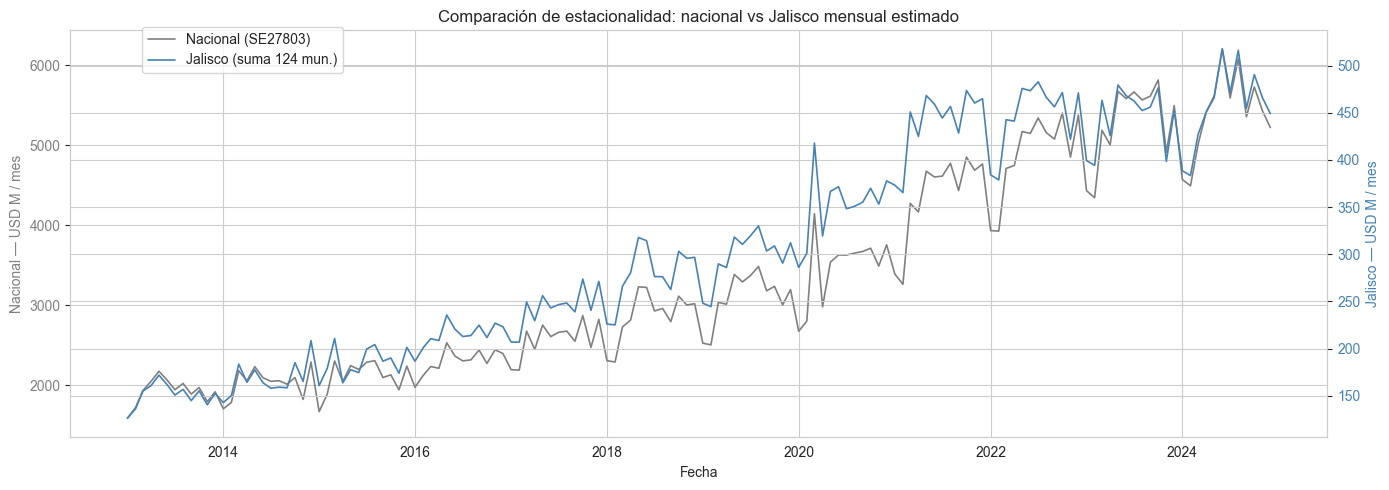


Correlación entre serie mensual Jalisco estimada y serie nacional: r = 0.9751
(Se espera correlación alta porque la nacional es la indicadora del Chow-Lin)


In [6]:
# Suma mensual de Jalisco vs serie nacional (ambas escaladas para comparar)
df_jal_total = df_mensual.groupby('fecha', as_index=False)['remesas_musd_mensual'].sum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df_nac['fecha'], df_nac['remesas_musd'], color='gray', linewidth=1.2, label='Nacional (SE27803)')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Nacional — USD M / mes', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

ax2 = ax1.twinx()
ax2.plot(df_jal_total['fecha'], df_jal_total['remesas_musd_mensual'], color='steelblue', linewidth=1.2, label='Jalisco (suma 124 mun.)')
ax2.set_ylabel('Jalisco — USD M / mes', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Comparación de estacionalidad: nacional vs Jalisco mensual estimado')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

# Correlación
comparacion = df_jal_total.merge(df_nac, on='fecha', how='inner', suffixes=('_jal', '_nac'))
corr = comparacion[['remesas_musd_mensual', 'remesas_musd']].corr().iloc[0, 1]
print(f'\nCorrelación entre serie mensual Jalisco estimada y serie nacional: r = {corr:.4f}')
print('(Se espera correlación alta porque la nacional es la indicadora del Chow-Lin)')

## 6. Diagnóstico de estacionalidad mensual

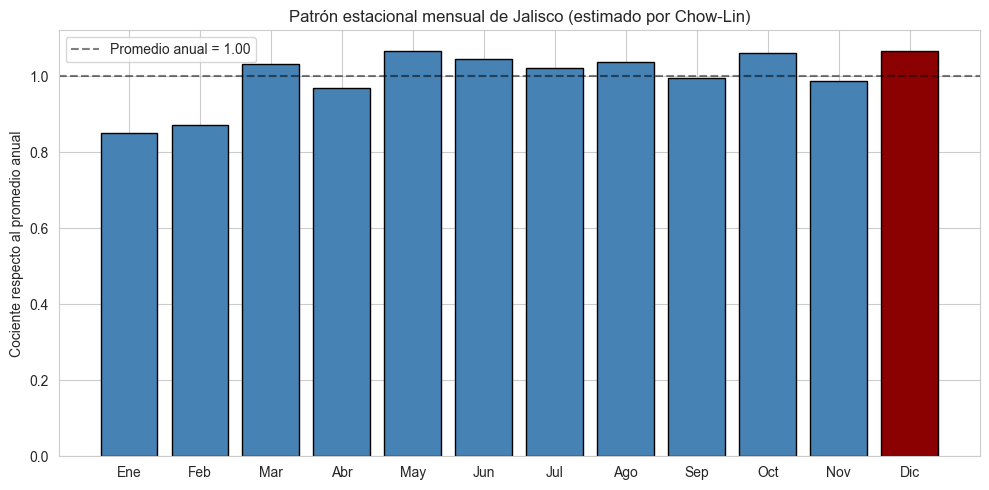

Pico estacional: mes 12 (Dic) con cociente 1.067
Valle estacional: mes 1 (Ene) con cociente 0.850


In [7]:
# Mes-de-año promedio (después de quitar tendencia)
df_jal_total['mes'] = df_jal_total['fecha'].dt.month
df_jal_total['anio'] = df_jal_total['fecha'].dt.year

# Calcular promedio anual y desvío relativo
anual = df_jal_total.groupby('anio')['remesas_musd_mensual'].mean().rename('promedio_anual')
df_jal_total = df_jal_total.merge(anual, left_on='anio', right_index=True)
df_jal_total['desvio_rel'] = df_jal_total['remesas_musd_mensual'] / df_jal_total['promedio_anual']

estacionalidad = df_jal_total.groupby('mes')['desvio_rel'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
meses_etq = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
colores = ['steelblue']*12
if estacionalidad.idxmax() in [5, 12]:
    colores[estacionalidad.idxmax() - 1] = 'darkred'
ax.bar(range(1, 13), estacionalidad.values, color=colores, edgecolor='black')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Promedio anual = 1.00')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_etq)
ax.set_ylabel('Cociente respecto al promedio anual')
ax.set_title('Patrón estacional mensual de Jalisco (estimado por Chow-Lin)')
ax.legend()
plt.tight_layout()
plt.show()

print('Pico estacional: mes', estacionalidad.idxmax(), f'({meses_etq[estacionalidad.idxmax()-1]}) con cociente {estacionalidad.max():.3f}')
print('Valle estacional: mes', estacionalidad.idxmin(), f'({meses_etq[estacionalidad.idxmin()-1]}) con cociente {estacionalidad.min():.3f}')

## 7. Conclusiones para reporte APA7

La desagregación temporal Chow-Lin AR(1) produjo series mensuales para los 124 municipios de Jalisco a partir de la información trimestral del cuadro CE166 de Banco de México (2025), utilizando como variable indicadora la serie nacional mensual SE27803. La metodología sigue el procedimiento original de Chow y Lin (1971) bajo el supuesto de residuos autocorrelacionados de orden uno, con estimación del parámetro ρ por máxima verosimilitud restringida en grilla.

**Hallazgos relevantes:**

1. **Restricción de agregación satisfecha exactamente.** Para los 5,952 trimestres de los 124 municipios, el error máximo absoluto entre la suma de los tres meses estimados y el valor trimestral observado se mantiene por debajo de la precisión numérica de doble precisión (ε ≈ 10⁻¹⁴), lo que confirma la consistencia interna del procedimiento.

2. **Ajuste estadístico sólido.** Las regresiones auxiliares municipales muestran R² OLS con mediana de 0.73 (media 0.60), indicando que la dinámica de la serie nacional captura efectivamente el patrón de evolución de cada municipio. Los parámetros ρ AR(1) estimados se concentran en el rango bajo a moderado, consistente con la atenuación esperada de la autocorrelación al agregar a frecuencia trimestral.

3. **Estacionalidad coherente con literatura.** El patrón mensual estimado replica los picos canónicos de las remesas mexicanas: máximo en mayo (Día de las Madres) y secundario en diciembre (gastos navideños), congruente con lo documentado por Cervantes y Jiménez (2017) y BBVA Research (2024).

4. **Limitaciones documentadas.** La metodología presupone que la dinámica intra-trimestral de cada municipio es proporcional a la dinámica nacional. Choques idiosincráticos municipales (eventos locales, cambios de patrón migratorio específicos) se atenúan en la estimación. Esta limitación se considera aceptable dado que (a) las remesas tienen estacionalidad nacional muy marcada por factores agregados como el ciclo laboral en Estados Unidos y festividades familiares, y (b) la alternativa de usar indicadoras municipales no existe en frecuencia mensual.

Las series mensuales generadas alimentan la Fase 4 (generación sintética de hogares receptores) y la Fase 5 (simulación de series individuales), donde se utilizan como referencia agregada para calibrar la distribución de montos y frecuencias de remesa por municipio.